In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
plt.rcParams['image.cmap'] = 'Oranges'

In [7]:
maze5x9 = [
    "#######",
    "#     #",
    "#     #",
    "#     #",
    "#     #",
    "#  S  #",
    "#     #",
    "#     #",
    "#     #",
    "#     #",
    "#######",
]

In [8]:
Actions = [(0, 1), (-1, 0), (0, -1), (1, 0)]
class Env:
    """2d gridworld environment"""
    def __init__(self, maze, step_reward=0):
        self.maze = maze
        self.step_reward = step_reward
        self.state_visit = np.zeros((self.height(), self.width()))
        self.state_action_visit = np.zeros((self.height(), self.width(), len(Actions)))
        self.reset()
    def reset(self):
        """initialize to begin with a new episode"""
        self.state = self.find_start_state()
        self.state_visit[self.state[0], self.state[1]] += 1
        return self.state, self.state_visit  # observation, info
    def step(self, action):
        """take an action and return tuple of state, reard, terminal, ..."""
        assert 0 <= action < 4
        neighbor = self.state + Actions[action]
        self.state_action_visit[self.state[0], self.state[1], action] += 1
        if not self.passable(neighbor):
            neighbor = self.state - Actions[action]
        self.state = neighbor
        self.state_visit[self.state[0], self.state[1]] += 1
        if self.is_goal(self.state):
            return self.state, self.reward(neighbor), True, False, self.state_visit
        # obs., r, terminal,, info
        return self.state, self.step_reward, False, False, self.state_visit 
    def height(self):
        return len(self.maze)
    def width(self):
        return len(self.maze[0])
    def find_start_state(self):
        """find a start position denoted by letter 'S' in maze"""
        for y in range(self.height()):
            if 'S' in self.maze[y]:
                return np.array([y, self.maze[y].index('S')])
        raise RuntimeError('find_start_state failed')
    def passable(self, yx):
        """return maze at yx is passable"""
        return self.maze[yx[0]][yx[1]] != '#'
    def is_goal(self, yx):
        """return maze at yx is a goal"""
        return self.maze[yx[0]][yx[1]].isdigit()
    def reward(self, yx):
        """return a reward on arriving state yx"""
        return int(self.maze[yx[0]][yx[1]]) if self.is_goal(yx) else 0

In [9]:
env = Env(maze5x9)
env.width(), env.height(), env.find_start_state()

(7, 11, array([5, 3]))

In [10]:
class LinearQTable(torch.nn.Module):
    """linear function approximation of Q-tables combiend for N options"""
    def __init__(self, env, N=8):
        super().__init__()
        self.N = N
        self.height = env.height()
        self.width = env.width()
        self.linear = torch.nn.Linear(2, N * len(Actions))
        with torch.no_grad():
            self.linear.weight *= 0.001
    def forward(self, yx_batch):
        return self.linear(yx_batch).reshape(-1, self.N, len(Actions))
    def infer_one(self, yx):
        return self.forward(torch.Tensor([yx]))[0]
    def query_all(self, xrange, yrange):
        x, y = np.meshgrid(xrange, yrange)
        yx = np.concatenate(np.dstack((y, x)))
        return self.forward(torch.Tensor(yx))
class LinearPredictor(torch.nn.Module):
    """predictor of skills given (s_0, s_f)"""
    def __init__(self, N=8):
        super().__init__()
        self.N = N
        self.linear = torch.nn.Linear(2*2, N)
    def forward(self, yx01_batch):
        return self.linear(yx01_batch)
    def infer_one(self, yx0, yx1):
        return self.forward(torch.Tensor([np.concatenate((yx0, yx1), axis=None)]))[0]
    def query_all(self, yx0, xrange, yrange):
        x, y = np.meshgrid(xrange, yrange)
        yx1 = np.concatenate(np.dstack((y, x)))
        input = np.hstack((np.expand_dims(yx0, axis=0).repeat(len(yx1), axis=0), yx1))
        return self.forward(torch.Tensor(input))

In [17]:
def sample_action(action_values, eps):
    p = random.random()
    if p < eps:
        return random.randrange(len(action_values))
    return action_values.argmax()
def Q_agent(env, q_table, predictor, step_limit, *,
              N=8, eps=0.5, gamma=0.95):
    obs, info = env.reset()
    num_episodes = 1
    skill = random.randint(0, N-1)
    optimizer_pred = torch.optim.SGD(predictor.parameters(), lr=0.001, momentum=0.9)
    optimizer = torch.optim.SGD(q_table.parameters(), lr=0.001, momentum=0.9)
    step = 0
    episode = []
    s0 = obs
    while step < step_limit:
        # step
        step += 1
        q_values_all = q_table.infer_one(obs)
        action_values = q_values_all[skill].detach().numpy()
        at = sample_action(action_values, eps)
        next_obs, _r_, _terminal_, _interrupt_, info = env.step(at)
        assert not (_terminal_ or _interrupt_) # in this env
        episode += [obs, at, next_obs]
        obs = next_obs
        # epilogue
        skill_terminate = _terminal_ or _interrupt_ or random.random() < (1-gamma)
        if skill_terminate:
            # train
            optimizer_pred.zero_grad()
            a = torch.Tensor(predictor.infer_one(s0, obs)).unsqueeze(0)
            b = torch.Tensor([skill]).long()
            pred_loss = torch.nn.functional.cross_entropy(a, b)
            pred_loss.backward()
            optimizer_pred.step()
            
            optimizer.zero_grad()
            with torch.no_grad():
                logits = predictor.infer_one(s0, obs)
            m = torch.distributions.Categorical(logits=logits)
            reward = m.log_prob(torch.Tensor([skill])).item()
            o = episode[0::3]
            a = episode[1::3]
            op = episode[2::3]
            assert len(episode) >= 3
            r = [0.] * (len(episode) // 3)
            r[-1] = reward
            
            target = torch.from_numpy(np.array(r)).float().unsqueeze(-1).repeat(1, N)
            successor_mask = np.ones(len(r), dtype=bool)
            successor_mask[-1] = False
            to = torch.from_numpy(np.array(o)).float()
            q_values_all = q_table(to)
            with torch.no_grad():
                _, vals = q_table(torch.from_numpy(np.array(op)).float()).max(-1)
                target += gamma * vals * torch.from_numpy(successor_mask).unsqueeze(-1).repeat(1, N)
            action_index = torch.Tensor(a).to(torch.int64).unsqueeze(-1).unsqueeze(-1).repeat(1, N, 1)
            q_values = q_values_all.gather(1, action_index)
            loss = torch.nn.functional.mse_loss(q_values, target.unsqueeze(-1))
            loss.backward()
            optimizer.step()
            # prologue
            num_episodes += 1
            skill = random.randint(0, N-1)
            episode = []
            s0 = obs
    return num_episodes

In [18]:
env = Env(maze5x9)
q_table = LinearQTable(env)
predictor = LinearPredictor()
Q_agent(env, q_table, predictor, 10000, eps=0.2)

511

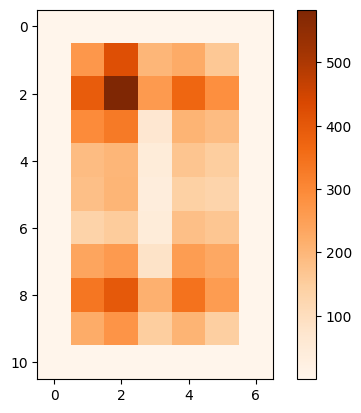

In [19]:
plt.imshow(env.state_visit+0.01)
plt.colorbar()

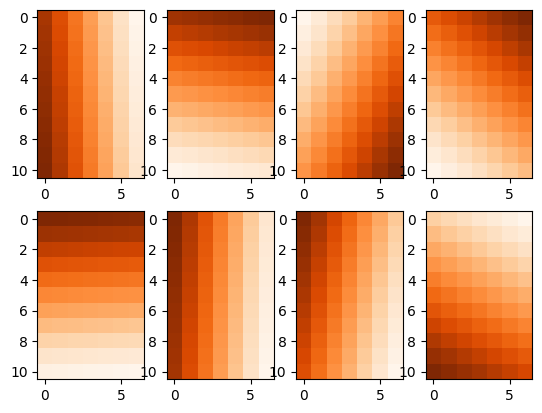

In [20]:
yx0 = np.array([3,5])
with torch.no_grad():
    vt = predictor.query_all(yx0, range(7), range(11)).to('cpu').numpy()
 
N = len(vt[0])
for i in range(N):
    ax = plt.subplot(2, N//2, i+1)
    ax.imshow(vt[:,i].reshape(11, 7))
plt.show()

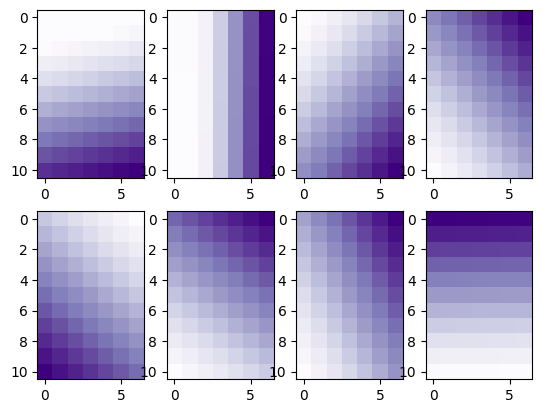

In [21]:
with torch.no_grad():
    qmap = q_table.query_all(range(7), range(11)).to('cpu').numpy()
N = qmap.shape[1] # S, N, A
for i in range(N):
    ax = plt.subplot(2, N//2, i+1)
    ax.imshow(qmap[:,i,:].reshape(11, 7, 4).max(axis=2), cmap='Purples')
plt.show()

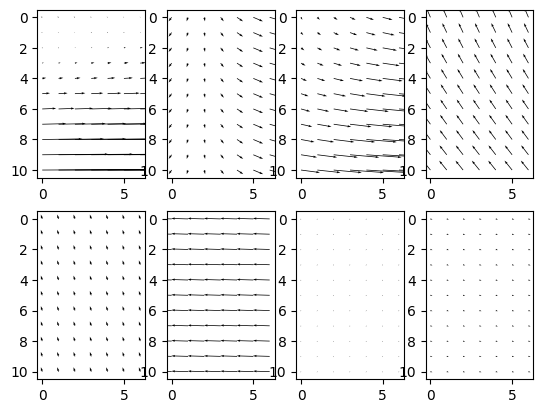

In [22]:
eps = 1e-8
X, Y = np.meshgrid(np.linspace(0, 6, 7), np.linspace(0, 10, 11))
for i in range(N):
    ax = plt.subplot(2, N//2, i+1)
    qsa = qmap[:,i,:]
    p4 = np.exp(qsa - qsa.max())
    p4 /= max(eps, p4.sum())
    uv = p4 @ Actions
    uv = uv.reshape(11,7,2)
    # print(uv)
    U = uv[:,:,0]
    V = uv[:,:,1]
    ax.invert_yaxis()
    ax.quiver(X, Y, V, U, angles='xy', scale_units='xy', scale=5e-3)
plt.show()